# Llama3-8B 가중치 채널별 Boxplot

이 노트북은 `Meta-Llama-3-8B`의 2D 가중치(주로 Linear weight)에서,
- 출력 채널(`out_features`, row) 기준 boxplot
- 입력 채널(`in_features`, column) 기준 boxplot
을 그립니다.

기본적으로 전체 모델을 로드하지 않고 `safetensors`에서 필요한 텐서만 읽습니다.


In [1]:
from pathlib import Path
from collections import defaultdict
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from safetensors import safe_open

plt.rcParams["figure.dpi"] = 120


In [2]:
# 모델 경로 자동 선택
CANDIDATE_MODEL_PATHS = [
    "/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B",
    "/workspace/Weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B",
]

MODEL_DIR = next((Path(p) for p in CANDIDATE_MODEL_PATHS if Path(p).exists()), None)
if MODEL_DIR is None:
    raise FileNotFoundError(
        "Meta-Llama-3-8B 경로를 찾지 못했습니다. CANDIDATE_MODEL_PATHS를 수정하세요."
    )

INDEX_PATH = MODEL_DIR / "model.safetensors.index.json"
if not INDEX_PATH.exists():
    raise FileNotFoundError(f"index 파일이 없습니다: {INDEX_PATH}")

print(f"MODEL_DIR: {MODEL_DIR}")
print(f"INDEX_PATH: {INDEX_PATH}")


MODEL_DIR: /home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B
INDEX_PATH: /home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B/model.safetensors.index.json


In [3]:
def build_weight_maps(model_dir: Path):
    index = json.loads((model_dir / "model.safetensors.index.json").read_text())
    weight_map = index["weight_map"]

    shard_to_keys = defaultdict(list)
    for name, shard in weight_map.items():
        shard_to_keys[shard].append(name)

    return weight_map, shard_to_keys


def collect_2d_weight_info(model_dir: Path, shard_to_keys, include_tokens=None, exclude_tokens=None):
    rows = []
    include_tokens = include_tokens or []
    exclude_tokens = exclude_tokens or []

    for shard, keys in shard_to_keys.items():
        with safe_open(str(model_dir / shard), framework="pt", device="cpu") as f:
            for name in keys:
                if include_tokens and not any(tok in name for tok in include_tokens):
                    continue
                if exclude_tokens and any(tok in name for tok in exclude_tokens):
                    continue

                shape = f.get_slice(name).get_shape()
                if len(shape) == 2:
                    rows.append(
                        {
                            "name": name,
                            "out_features": shape[0],
                            "in_features": shape[1],
                            "shard": shard,
                        }
                    )

    rows.sort(key=lambda x: x["name"])
    return rows


def search_weight_names(weight_info, keyword: str, limit: int = 30):
    hits = [row for row in weight_info if keyword in row["name"]]
    print(f"{keyword!r} 검색 결과: {len(hits)}개")
    for row in hits[:limit]:
        print(f"- {row['name']}  ({row['out_features']} x {row['in_features']})")
    return hits


WEIGHT_MAP, SHARD_TO_KEYS = build_weight_maps(MODEL_DIR)
WEIGHT_INFO_2D = collect_2d_weight_info(
    MODEL_DIR,
    SHARD_TO_KEYS,
    include_tokens=["self_attn", "mlp", "lm_head", "embed_tokens"],
)

print(f"전체 텐서 수: {len(WEIGHT_MAP)}")
print(f"2D 텐서 수(필터 적용): {len(WEIGHT_INFO_2D)}")
print("예시 10개:")
for row in WEIGHT_INFO_2D[:10]:
    print(f"- {row['name']} ({row['out_features']} x {row['in_features']})")


전체 텐서 수: 291
2D 텐서 수(필터 적용): 226
예시 10개:
- lm_head.weight (128256 x 4096)
- model.embed_tokens.weight (128256 x 4096)
- model.layers.0.mlp.down_proj.weight (4096 x 14336)
- model.layers.0.mlp.gate_proj.weight (14336 x 4096)
- model.layers.0.mlp.up_proj.weight (14336 x 4096)
- model.layers.0.self_attn.k_proj.weight (1024 x 4096)
- model.layers.0.self_attn.o_proj.weight (4096 x 4096)
- model.layers.0.self_attn.q_proj.weight (4096 x 4096)
- model.layers.0.self_attn.v_proj.weight (1024 x 4096)
- model.layers.1.mlp.down_proj.weight (4096 x 14336)


In [4]:
import gc


def _channel_scale_gap(weight: torch.Tensor, q_low: float = 0.05, q_high: float = 0.95, eps: float = 1e-12):
    out_scales = torch.sqrt(torch.mean(weight * weight, dim=1))
    in_scales = torch.sqrt(torch.mean(weight * weight, dim=0))

    out_q_low = torch.quantile(out_scales, q_low).item()
    out_q_high = torch.quantile(out_scales, q_high).item()
    in_q_low = torch.quantile(in_scales, q_low).item()
    in_q_high = torch.quantile(in_scales, q_high).item()

    out_gap = out_q_high / max(out_q_low, eps)
    in_gap = in_q_high / max(in_q_low, eps)

    return out_gap, in_gap


def rank_layer_weights_by_channel_gap(model_dir: Path, weight_map: dict, weight_info_2d,
                                      q_low: float = 0.05, q_high: float = 0.95):
    rows = []

    for row in weight_info_2d:
        name = row["name"]
        if not name.startswith("model.layers."):
            continue

        shard = weight_map[name]
        with safe_open(str(model_dir / shard), framework="pt", device="cpu") as f:
            w = f.get_tensor(name).to(torch.float32)

        out_gap, in_gap = _channel_scale_gap(w, q_low=q_low, q_high=q_high)
        rows.append(
            {
                "name": name,
                "shape": (row["out_features"], row["in_features"]),
                "out_gap": out_gap,
                "in_gap": in_gap,
                "combined_gap": max(out_gap, in_gap),
            }
        )

        del w
        gc.collect()

    rows_out = sorted(rows, key=lambda x: x["out_gap"], reverse=True)
    rows_in = sorted(rows, key=lambda x: x["in_gap"], reverse=True)
    rows_combined = sorted(rows, key=lambda x: x["combined_gap"], reverse=True)
    return rows_out, rows_in, rows_combined


ROWS_OUT, ROWS_IN, ROWS_COMBINED = rank_layer_weights_by_channel_gap(
    MODEL_DIR,
    WEIGHT_MAP,
    WEIGHT_INFO_2D,
    q_low=0.05,
    q_high=0.95,
)

BEST_OUTPUT = ROWS_OUT[0]
BEST_INPUT = ROWS_IN[0]
BEST_COMBINED = ROWS_COMBINED[0]

print("[Best by output-channel gap]")
print(BEST_OUTPUT)
print()
print("[Best by input-channel gap]")
print(BEST_INPUT)
print()
print("[Best by combined max(output,input) gap]")
print(BEST_COMBINED)

print("\nTop-5 combined:")
for row in ROWS_COMBINED[:5]:
    print(f"- {row['name']} | out={row['out_gap']:.3f}, in={row['in_gap']:.3f}, shape={row['shape']}")


KeyboardInterrupt: 

In [ ]:
# 보고 싶은 weight 선택
# mode: 'best_combined' | 'best_output' | 'best_input' | 'manual'
TARGET_MODE = "best_combined"
MANUAL_TARGET_WEIGHT_NAME = "model.layers.0.self_attn.q_proj.weight"

if TARGET_MODE == "best_combined":
    TARGET_WEIGHT_NAME = BEST_COMBINED["name"]
elif TARGET_MODE == "best_output":
    TARGET_WEIGHT_NAME = BEST_OUTPUT["name"]
elif TARGET_MODE == "best_input":
    TARGET_WEIGHT_NAME = BEST_INPUT["name"]
elif TARGET_MODE == "manual":
    TARGET_WEIGHT_NAME = MANUAL_TARGET_WEIGHT_NAME
else:
    raise ValueError("TARGET_MODE는 'best_combined', 'best_output', 'best_input', 'manual' 중 하나여야 합니다.")

# 예시 검색
_ = search_weight_names(WEIGHT_INFO_2D, f"layers.{TARGET_WEIGHT_NAME.split('.')[2]}", limit=20)

if TARGET_WEIGHT_NAME not in WEIGHT_MAP:
    raise KeyError(
        f"{TARGET_WEIGHT_NAME} 이(가) index에 없습니다. search_weight_names로 이름을 먼저 확인하세요."
    )

print(f"TARGET_MODE: {TARGET_MODE}")
print(f"TARGET_WEIGHT_NAME: {TARGET_WEIGHT_NAME}")


'layers.0' 검색 결과: 7개
- model.layers.0.mlp.down_proj.weight  (4096 x 14336)
- model.layers.0.mlp.gate_proj.weight  (14336 x 4096)
- model.layers.0.mlp.up_proj.weight  (14336 x 4096)
- model.layers.0.self_attn.k_proj.weight  (1024 x 4096)
- model.layers.0.self_attn.o_proj.weight  (4096 x 4096)
- model.layers.0.self_attn.q_proj.weight  (4096 x 4096)
- model.layers.0.self_attn.v_proj.weight  (1024 x 4096)
TARGET_MODE: best_combined
TARGET_WEIGHT_NAME: model.layers.0.self_attn.q_proj.weight


In [ ]:
def load_weight_tensor(model_dir: Path, weight_map: dict, weight_name: str, dtype=torch.float32):
    shard = weight_map[weight_name]
    with safe_open(str(model_dir / shard), framework="pt", device="cpu") as f:
        weight = f.get_tensor(weight_name)
    if dtype is not None:
        weight = weight.to(dtype)
    return weight, shard


WEIGHT, SHARD_NAME = load_weight_tensor(MODEL_DIR, WEIGHT_MAP, TARGET_WEIGHT_NAME, dtype=torch.float32)
print(f"Loaded from: {SHARD_NAME}")
print(f"Shape: {tuple(WEIGHT.shape)}, dtype: {WEIGHT.dtype}")


Loaded from: model-00001-of-00007.safetensors
Shape: (4096, 4096), dtype: torch.float32


In [ ]:
def select_channel_indices(n_channels: int, max_channels: int = 128, sampling: str = "uniform", seed: int = 42):
    if max_channels is None or max_channels >= n_channels:
        return np.arange(n_channels)

    if sampling == "uniform":
        return np.linspace(0, n_channels - 1, max_channels, dtype=int)
    if sampling == "random":
        rng = np.random.default_rng(seed)
        return np.sort(rng.choice(n_channels, size=max_channels, replace=False))

    raise ValueError("sampling은 'uniform' 또는 'random'만 지원합니다.")


def draw_channel_boxplot(ax, weight: torch.Tensor, axis: str = "output", max_channels: int = 128,
                         sampling: str = "uniform", seed: int = 42, showfliers: bool = False):
    if axis not in {"output", "input"}:
        raise ValueError("axis는 'output' 또는 'input' 이어야 합니다.")

    arr = weight.detach().cpu().numpy()

    if axis == "output":
        n_channels = arr.shape[0]
        indices = select_channel_indices(n_channels, max_channels=max_channels, sampling=sampling, seed=seed)
        data = [arr[i, :] for i in indices]
        # xlabel = "Output channel index (row)"
    else:
        n_channels = arr.shape[1]
        indices = select_channel_indices(n_channels, max_channels=max_channels, sampling=sampling, seed=seed)
        data = [arr[:, j] for j in indices]
        # xlabel = "Input channel index (column)"
    xlabel = "Channel index"

    bp = ax.boxplot(data, showfliers=showfliers, widths=0.6)

    for med in bp["medians"]:
        med.set_color("#08519c")
        med.set_linewidth(1.1)

    ax.set_xlabel(xlabel, fontsize = 20)
    # ax.set_ylabel("Weight value")
    ax.set_ylabel("Range", fontsize = 20)
    ax.set_xticks([])
    ax.tick_params(axis='both', labelsize=15)  # 눈금 숫자 크기
    ax.grid(alpha=0.25, linestyle="--")


def plot_output_input_boxplots(weight: torch.Tensor, weight_name: str,
                               max_output_channels: int = 128,
                               max_input_channels: int = 128,
                               sampling: str = "uniform",
                               seed: int = 42,
                               showfliers: bool = False):
    fig, axes = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)

    draw_channel_boxplot(
        axes, weight,
        axis="input",
        max_channels=max_output_channels,
        sampling=sampling,
        seed=seed,
        showfliers=showfliers,
    )
    # axes[0].set_title(f"{weight_name} | Output-channel boxplot")
    # axes.set_title( r"$W_{q}$ | Input-channel")

    # draw_channel_boxplot(
    #     axes[1], weight,
    #     axis="input",
    #     max_channels=max_input_channels,
    #     sampling=sampling,
    #     seed=seed,
    #     showfliers=showfliers,
    # )
    # # axes[1].set_title(f"{weight_name} | Input-channel boxplot")
    # # axes[1].set_title(f"{weight_name} | Input-channel boxplot")
    # axes[1].set_title( r"$W_{q}$ |  Input-channel")
    plt.savefig(f"./plot/{weight_name.replace('.', '_')}_input_boxplot.pdf", dpi=150)
    plt.show()


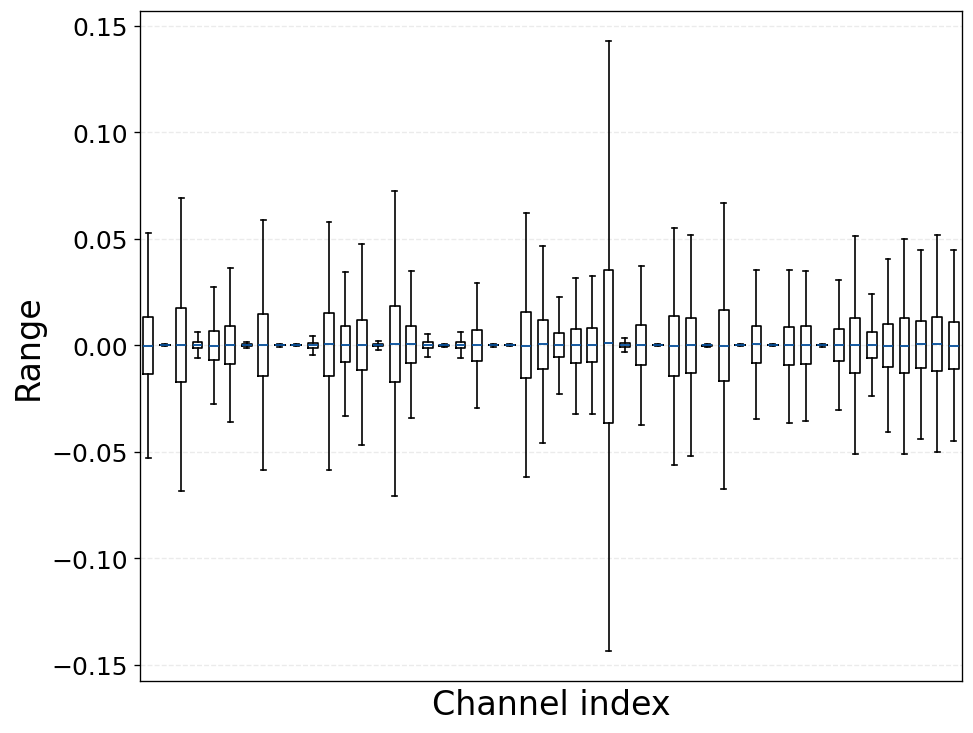

In [ ]:
# 실행
plot_output_input_boxplots(
    WEIGHT,
    TARGET_WEIGHT_NAME,
    max_output_channels=50,  # 채널 수가 너무 많으면 샘플링해서 그림
    max_input_channels=16,
    sampling="random",      # "uniform" or "random"
    seed=42,
    showfliers=False,
)


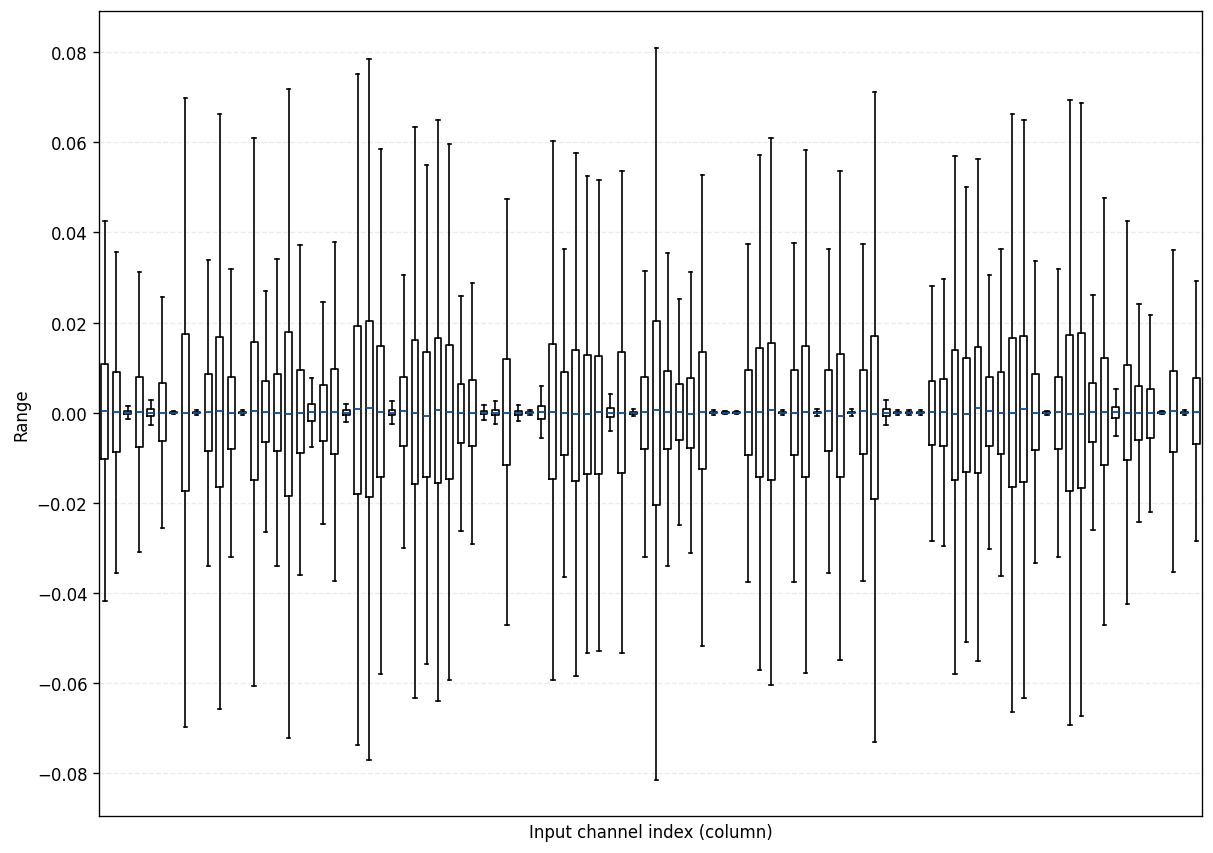

In [ ]:
# 여러 weight를 순차적으로 보고 싶을 때 예시
TARGETS = [
    "model.layers.0.self_attn.q_proj.weight",
    # "model.layers.1.self_attn.k_proj.weight",
    # "model.layers.0.self_attn.v_proj.weight",
    # "model.layers.0.mlp.up_proj.weight",
]

for name in TARGETS:
    w, _ = load_weight_tensor(MODEL_DIR, WEIGHT_MAP, name, dtype=torch.float32)
    plot_output_input_boxplots(
        w,
        name,
        max_output_channels=96,
        max_input_channels=96,
        sampling="uniform",
        showfliers=False,
    )
